# Домашнее задание 7. Сборка конвейера CI/CD
Если у вас еще нет аккаунта в GitLab, вам нужно будет его создать:
1. Перейдите на [GitLab](https://gitlab.com/) и войдите в свой аккаунт.
2. Нажмите на кнопку New Project (Новый проект).
3. Выберите Create blank project (Создать пустой проект).
4. Укажите имя проекта и описание (по желанию).
5. Выберите уровень видимости проекта (Public).
6. Нажмите Create project (Создать проект).
7. Дополните файл .gitlab-ci.yml необходимыми джобами и отправьте в репозиторий.

## 1. Настроить CI/CD-пайплайн для ML-сервиса с использованием GitLab




Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

Вам дан рабочий код пайплайна и черновик файла .gitlab-ci.yml. Перепишите yaml в [ячейке](#scrollTo=s55MrS66JXWs)


*Ожидаемый артефакт: список коммитов в [ячейке](#scrollTo=gErasBmRSHjb) и ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=F0uQqbe3iHqE)*    

### Подготовка локального репозитория и зависимостей

Работа выполнялась локально в папке проекта через PowerShell, поэтому команды инициализации Git, создания репозитория, файла  requirements.txt из ноутбука не запускаются и закомментированы. 

In [1]:
%pip install scikit-learn numpy pandas -qqq
#%%sh
#git config --global user.email "you@example.com"
#git config --global user.name "Your Name"
#git init
#pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


В рамках итогового проекта файл ml_pipeline.py уже подготовлен локально. Повторно перезаписывать его через %%writefile не нужно, потому что текущая версия используется CI/CD-пайплайном и сохраняет метрики в artifacts/metrics.json.


In [2]:
# %%writefile ml_pipeline.py
# import numpy as np
# import pandas as pd
# from sklearn.datasets import load_iris
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# iris = load_iris();X = iris.data ;y = iris.target
# hyperparameters={"n_estimators":100, "random_state":42}
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# model = RandomForestClassifier(**hyperparameters)
# model.fit(X_train, y_train);y_pred = model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# print(f'Точность аccuracy: {accuracy:.2f}')

### Проверяем работоспособность пайплайна

In [3]:
import os

PROJECT_DIR = r"C:\Users\perfe\OneDrive\Рабочий стол\МФТИ\2 семестр\РМ\ДЗ 7\hw7_cicd_project"

os.chdir(PROJECT_DIR)

print("Текущая папка проекта:")
print(os.getcwd())

Текущая папка проекта:
C:\Users\perfe\OneDrive\Рабочий стол\МФТИ\2 семестр\РМ\ДЗ 7\hw7_cicd_project


In [4]:
!python ml_pipeline.py

Точность accuracy: 0.90
Метрики сохранены в artifacts/metrics.json


### CI/CD-пайплайн в GitVerse

Так как GitLab.com потребовал identity verification для запуска pipeline, для выполнения шага 1 был использован GitVerse как аналог GitLab.  
Для GitVerse создан отдельный workflow-файл .gitverse/workflows/ci.yml. Он также создан локально, поэтому ячейка ниже закомментирована. 


In [5]:
# %%writefile .gitverse/workflows/ci.yml
# name: GitVerse ML Pipeline
#
# on:
#   push:
#     branches:
#       - main
#
# jobs:
#   make_pipeline_reproducible:
#     runs-on: ubuntu-latest
#     steps:
#       - uses: actions/checkout@v4
#
#       - name: Install dependencies
#         run: |
#           python --version
#           python -m pip install --break-system-packages -r requirements.txt
#
#       - name: Make pipeline reproducible
#         run: |
#           echo "Save dependencies, seed, model parameters and metrics"
#           python -m pip freeze | tee requirements.lock.txt
#           python ml_pipeline.py
#           cat artifacts/metrics.json
#
#   unit_tests:
#     runs-on: ubuntu-latest
#     steps:
#       - uses: actions/checkout@v4
#
#       - name: Install dependencies
#         run: |
#           python --version
#           python -m pip install --break-system-packages -r requirements.txt
#
#       - name: Run tests
#         run: python -m pytest -q
#
#   package_project:
#     runs-on: ubuntu-latest
#     steps:
#       - uses: actions/checkout@v4
#
#       - name: Check deployment files
#         run: |
#           test -f Dockerfile
#           test -f docker-compose.canary.yml
#           test -f nginx/current.conf
#           test -f README.md
#

In [6]:
from pathlib import Path

print(Path(".gitverse/workflows/ci.yml").read_text(encoding="utf-8"))

﻿name: GitVerse ML Pipeline

on:
  push:
    branches:
      - main

jobs:
  make_pipeline_reproducible:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Install dependencies
        run: |
          python --version
          python -m pip install --break-system-packages -r requirements.txt

      - name: Make pipeline reproducible
        run: |
          echo "Save dependencies, seed, model parameters and metrics"
          python -m pip freeze | tee requirements.lock.txt
          python ml_pipeline.py
          cat artifacts/metrics.json

  unit_tests:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Install dependencies
        run: |
          python --version
          python -m pip install --break-system-packages -r requirements.txt

      - name: Run tests
        run: python -m pytest -q

  package_project:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Check d

In [7]:
#!git add .gitlab-ci.yml ml_pipeline.py
#!git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitLab"
#!git log

### Проверка статуса пайплайна

После настройки файла .gitlab-ci.yml, вы можете закоммитить изменения и запушить их в репозиторий.

GitLab автоматически запустит пайплайн, и вы сможете наблюдать за его выполнением в разделе CI/CD своего проекта.

Что нужно сделать:

1. Перейдите в свой проект на GitLab.
2. Нажмите на вкладку CI/CD и выберите Pipelines.
3. Вы увидите список запущенных пайплайнов. Нажмите на последний, чтобы увидеть выполнение.
4. Убедитесь, что все джобы выполнены успешно (отмечены зеленым цветом).
5. Приложите ссылку на статус выполнения в разделе Pipelines **своего** репозитория на GitLab.

Ссылка на выполненный пайплайн GitLab:

text
https://gitverse.ru/TatianaPanfilova/MLops_HW7/cicd/4


Что должно быть видно на скриншоте: pipeline завершился успешно, jobs make_pipeline_reproducible, unit_tests, package_project зеленые.


### Результат настройки CI/CD-пайплайна

Изначально был создан публичный проект в GitLab:

https://gitlab.com/panfilovatp-group/MLops_HW7

Однако запуск GitLab CI/CD на GitLab.com оказался недоступен из-за требования платформы пройти identity verification для запуска pipelines. Поэтому в соответствии с условием задания, где разрешено использовать аналоги GitLab, был использован GitVerse.

Публичный репозиторий GitVerse:

https://gitverse.ru/TatianaPanfilova/MLops_HW7

Ссылка на успешно выполненный CI/CD-пайплайн GitVerse:

https://gitverse.ru/TatianaPanfilova/MLops_HW7/cicd/4

В пайплайне успешно выполнены три задания:

- make_pipeline_reproducible;
- unit_tests;
- package_project.

Основной коммит с успешным запуском пайплайна:

- 08adb4f remove pip upgrade from gitverse workflow

Основные коммиты, связанные с настройкой CI/CD-пайплайна:

- d554101 — initial project for HW7 CI/CD: добавлена начальная структура проекта.
- 788abb6 — fix gitlab ci yaml: подготовлен .gitlab-ci.yml для GitLab CI/CD.
- 2c86e8e — add gitverse ci workflow: добавлен workflow для GitVerse как аналога GitLab.
- cd035d0 — fix gitverse workflow checkout: исправлен запуск checkout в GitVerse CI/CD.
- 9cb04aa — fix gitverse pip install: исправлена установка зависимостей в GitVerse.

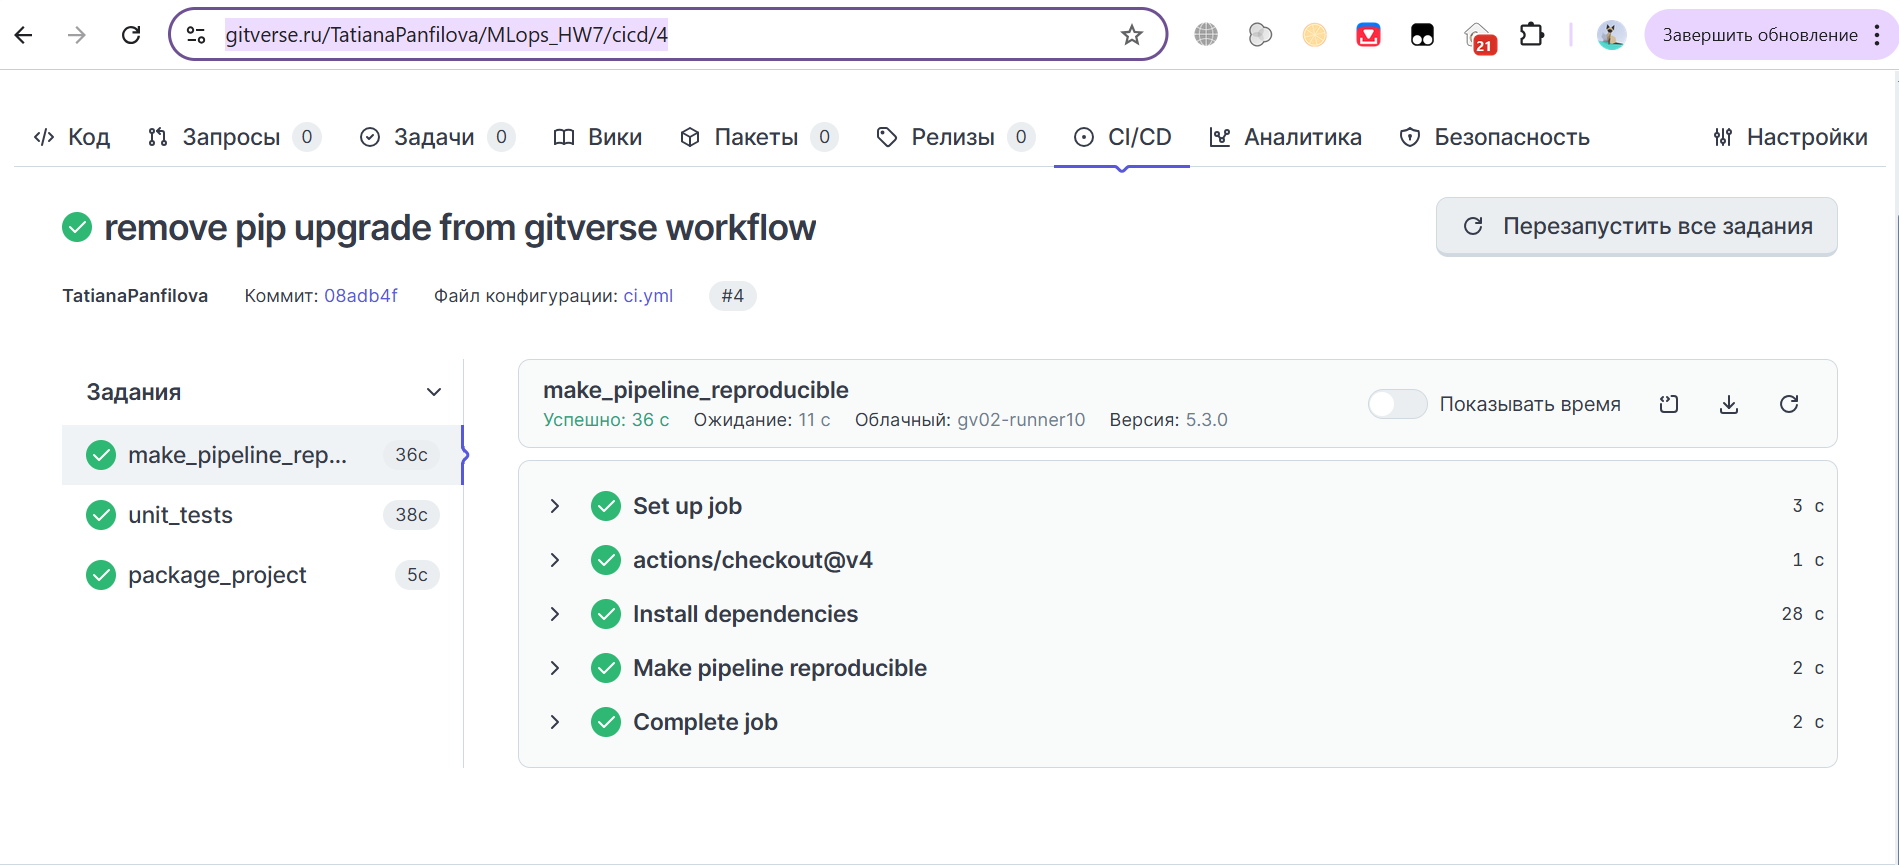

## 2. Обосновать стратегию деплоя (развертывания, Blue-Green, Canary, Rolling, Shadow) и оценить влияние на риски




Изучите [инструмент](https://github.com/npryce/adr-tools) для учета архитектурных решений и запишите **причины**, по которым мы начали использовать стратегию деплоя и **риски**, к которым нас привело такое решение.



*Ожидаемый артефакт: архитектурное решение в формате ADR в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

## ADR: использовать Canary Deployment для ML-сервиса

**Статус:** принято

### Контекст

В задании требуется выбрать стратегию безопасного развертывания ML-сервиса и оценить влияние этой стратегии на риски. По условию в коде отсутствует полноценная обработка ошибок, поэтому новая версия сервиса не должна сразу получать весь трафик.

Для проекта подготовлены две версии сервиса: стабильная v1.0.0 и новая v1.1.0. Нужно выбрать способ деплоя, при котором можно проверить новую версию и при необходимости быстро вернуться к стабильной.

### Рассмотренные варианты

**Blue-Green Deployment** позволяет держать две версии сервиса параллельно и быстро переключать трафик между ними. Это удобно для отката, но при переключении новая версия может сразу получить весь трафик. Если ошибка проявится только после переключения, риск будет резким.

**Canary Deployment** позволяет сначала направить на новую версию небольшую долю трафика. Это снижает риск полного отказа сервиса, потому что новая версия проверяется постепенно. Такой вариант лучше подходит для текущей задачи, так как можно начать с небольшой доли запросов и затем увеличить её.

**Rolling Deployment** постепенно заменяет старые инстансы новыми. Этот вариант экономит ресурсы, но хуже подходит для явного сравнения двух версий модели и быстрого возврата всего трафика на старую версию.

**Shadow Deployment** позволяет отправлять копию реального трафика на новую версию без влияния на пользователей. Это безопасный вариант, но он требует дополнительной инфраструктуры для копирования запросов и не проверяет полноценный пользовательский сценарий с ответом новой модели.

### Решение

Для проекта выбрана стратегия **Canary Deployment**.

В реализации используется Nginx как балансировщик. Стабильная версия сервиса имеет версию v1.0.0, новая версия — v1.1.0.

Сначала трафик распределяется в пропорции 90/10: большая часть запросов идет на стабильную версию, небольшая часть — на новую. Если новая версия проходит проверки /health и /predict, долю трафика можно увеличить до 50/50, а затем до 100%.

Если новая версия работает нестабильно, выполняется rollback: весь трафик возвращается на стабильную версию v1.0.0.

### Влияние на риски

Canary Deployment снижает риск того, что ошибка новой версии сразу повлияет на весь сервис. Новая версия получает только часть трафика, поэтому проблему можно обнаружить до полного переключения.

Также эта стратегия снижает риск сложного отката: при ошибке достаточно вернуть конфигурацию Nginx так, чтобы весь трафик снова шел на v1.0.0.

Но решение добавляет и новые риски. Нужно поддерживать несколько конфигураций Nginx, проверять правильность распределения трафика и отдельно тестировать rollback. Если балансировщик настроен неверно, новая версия может получить не ту долю трафика, которая планировалась.

### Проверка решения

В проекте реализован Canary Deployment:

- обе версии сервиса доступны отдельно;
- Nginx распределяет трафик между версиями;
- предусмотрены конфигурации 90/10, 50/50, 100%;
- предусмотрен rollback на стабильную версию v1.0.0;
- работа проверяется через эндпоинты /health и /predict.

### Итог

Canary Deployment выбран как компромисс между безопасностью и сложностью реализации. Он лучше подходит для сервиса без полноценной обработки ошибок, потому что позволяет постепенно выкатывать новую версию и быстро откатиться при проблемах.

### Где находится реализация выбранной стратегии

ADR выше фиксирует архитектурное решение: для проекта выбрана стратегия Canary Deployment.  
Сама реализация и проверка этой стратегии показаны в следующих шагах домашнего задания.

Основные файлы проекта:

- docker-compose.canary.yml — запуск двух версий ML-сервиса и Nginx-балансировщика для Canary Deployment;
- docker-compose.blue.yml — отдельный запуск версии v1.0.0;
- docker-compose.green.yml — отдельный запуск версии v1.1.0;
- папка nginx — конфигурации Nginx для распределения трафика и rollback;
- scripts/switch_canary.sh — переключение режимов Canary: 90/10, 50/50, 100%, rollback;
- папка app — код FastAPI ML-сервиса с эндпоинтами /health и /predict;
- папка doc/architecture/decisions — ADR-файл с архитектурным решением;
- .gitverse/workflows/ci.yml — CI/CD workflow для GitVerse;
- .github/workflows/deploy.yml — workflow для GitHub Actions;
- README.md — инструкция по запуску и проверке проекта.

В следующих разделах проверяется, что обе версии сервиса доступны, Nginx распределяет трафик между ними, а при ошибке можно выполнить rollback на стабильную версию v1.0.0.

## 3. Реализовать стратегию развертывания

Реализуйте стратегию, выбранную на предыдущем [шаге](#scrollTo=hoQdM6SrJXXE).



*Ожидаемый артефакт: yaml в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

Для реализации выбранной стратегии используется docker-compose.canary.yml.  
Файл уже создан в проекте и повторно не перезаписывается из ноутбука.

In [19]:
# Содержимое файла:
#
# services:
#   ml-service-v1:
#     build: .
#     container_name: hw7-ml-service-v1
#     environment:
#       MODEL_VERSION: "v1.0.0"
#       RANDOM_STATE: "42"
#     ports:
#       - "8001:8000"
#     healthcheck:
#       test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')"]
#       interval: 10s
#       timeout: 3s
#       retries: 3
#
#   ml-service-v2:
#     build: .
#     container_name: hw7-ml-service-v2
#     environment:
#       MODEL_VERSION: "v1.1.0"
#       RANDOM_STATE: "42"
#     ports:
#       - "8002:8000"
#     healthcheck:
#       test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')"]
#       interval: 10s
#       timeout: 3s
#       retries: 3
#
#   nginx:
#     image: nginx:1.27-alpine
#     container_name: hw7-canary-nginx
#     depends_on:
#       ml-service-v1:
#         condition: service_healthy
#       ml-service-v2:
#         condition: service_healthy
#     ports:
#       - "8080:80"
#     volumes:
#       - ./nginx/current.conf:/etc/nginx/conf.d/default.conf:ro

В этой конфигурации обе версии сервиса запускаются одновременно.  
Версия v1.0.0 доступна на порту 8001, версия v1.1.0 — на порту 8002.  
Балансировщик Nginx доступен на порту 8080 и использует файл nginx/current.conf.

Переключение режимов Canary и rollback реализованы через конфигурации в папке nginx и скрипт scripts/switch_canary.sh. Проверка работы будет показана далее через запросы к /health и /predict.

## 4. Спланировать A/B-тестирование для ML-модели

Вспомните материалы [семинара](https://colab.research.google.com/drive/1TM1yieSFhUqVxBferzbcexpAtK00lGYe?usp=sharing) и опишите параметры эксперимента.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=OluzjqEhaIpM)*

### План A/B-тестирования для ML-модели

В A/B-тесте сравниваются две версии ML-сервиса:

- контрольная группа — v1.0.0;
- тестовая группа — v1.1.0.

Основная метрика — доля корректных предсказаний после получения фактической разметки.  
Дополнительно контролируются технические метрики: ошибки /predict, статус /health и задержка ответа.

Для расчета размера выборки используется нормальная аппроксимация для сравнения двух независимых долей.

In [25]:
from math import ceil, sqrt
import pandas as pd

alpha = 0.05
power = 0.80

baseline_accuracy = 0.90
mde = 0.05
new_accuracy = baseline_accuracy + mde

z_alpha_2 = 1.96
z_beta = 0.84

p_pool = (baseline_accuracy + new_accuracy) / 2

n_per_group = (
    (
        z_alpha_2 * sqrt(2 * p_pool * (1 - p_pool))
        + z_beta * sqrt(
            baseline_accuracy * (1 - baseline_accuracy)
            + new_accuracy * (1 - new_accuracy)
        )
    )
    ** 2
    / (new_accuracy - baseline_accuracy) ** 2
)

n_per_group = ceil(n_per_group)

ab_test_plan = pd.DataFrame(
    {
        "Параметр": [
            "Контрольная версия",
            "Тестовая версия",
            "Основная метрика",
            "alpha",
            "power",
            "baseline accuracy",
            "MDE",
            "Размер выборки на группу",
            "Общий размер выборки",
            "Начальное распределение трафика",
        ],
        "Значение": [
            "v1.0.0",
            "v1.1.0",
            "доля корректных предсказаний",
            alpha,
            power,
            baseline_accuracy,
            mde,
            n_per_group,
            2 * n_per_group,
            "90/10",
        ],
    }
)

ab_test_plan

,Параметр,Значение
0,Контрольная версия,v1.0.0
1,Тестовая версия,v1.1.0
2,Основная метрика,доля корректных предсказаний
3,alpha,0.05
4,power,0.8
5,baseline accuracy,0.9
6,MDE,0.05
7,Размер выборки на группу,434
8,Общий размер выборки,868
9,Начальное распределение трафика,90/10


При выбранных параметрах A/B-теста требуется не менее 435 наблюдений на каждую группу.

Если версия v1.1.0 не ухудшает качество модели и технические метрики, долю трафика можно увеличивать. Если появляются ошибки /predict, нестабильный /health или ухудшение основной метрики, выполняется rollback на v1.0.0.

## 5. Создать CI/CD-пайплайн для ML-сервиса с использованием GitHub Actions



*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*



### CI/CD-пайплайн через GitHub Actions

Для GitHub Actions используется workflow-файл .github/workflows/ci.yml.  
Файл уже создан в папке проекта, поэтому в ноутбуке он не перезаписывается через %%writefile.

Workflow запускается при push в ветку main и выполняет три шага:

- устанавливает зависимости из requirements.txt;
- запускает ml_pipeline.py и проверяет сохранение metrics.json;
- запускает unit-тесты через pytest.

Команды git add, git commit и git push выполнялись локально через PowerShell, поэтому в ноутбуке они не запускаются повторно.

Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

In [26]:
#%%writefile ml_pipeline.py
#import numpy as np
#import pandas as pd
#from sklearn.datasets import load_iris
#from sklearn.model_selection import train_test_split
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import accuracy_score
#iris = load_iris();X = iris.data ;y = iris.target
#hyperparameters={"n_estimators":100, "random_state":42}
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#model = RandomForestClassifier(**hyperparameters)
#model.fit(X_train, y_train);y_pred = model.predict(X_test)
#accuracy = accuracy_score(y_test, y_pred)
#print(f'Точность аccuracy: {accuracy:.2f}')

Проверяем работоспособность пайплайна

In [27]:
#!python ml_pipeline.py

Вам дан рабочий код пайплайна и черновик файла ci.yml. Используйте GitHub Actions и перепишите [шаг](#scrollTo=NGcDFbCFJXV_) name: Make pipeline reproducible

GitHub Actions workflow подготовлен в папке .github/workflows

In [30]:
print(Path(".github/workflows/ci.yml").read_text(encoding="utf-8"))

name: CI

on:
  push:
    branches: [ main ]
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Make pipeline reproducible
        run: |
          python --version
          pip freeze | tee requirements.lock.txt
          python ml_pipeline.py
          cat artifacts/metrics.json

      - name: Run tests
        run: pytest -q


Копируем ci.yml в правильную директорию .github/workflows

In [31]:
#!mkdir -p .github/workflows
#!mv ci.yml ./.github/workflows/ci.yml

Начинаем отправку в репозиторий

In [32]:
#!git add ./.github/workflows/ci.yml ml_pipeline.py
#!git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitHub Actions"
#!git log

После настройки workflow каждый раз при пуше в репозиторий GitHub Actions будет автоматически запускать конвейер. Пожалуйста, приложите ссылку на статус выполнения в разделе Actions **своего** репозитория на GitHub.


*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*

Ссылка на выполненный GitHub Actions workflow:

https://github.com/PanfilovaTP/MLops_HW7/actions/runs/25328852721

На скриншоте видно, что workflow CI завершился со статусом Success, а job test выполнена успешно.

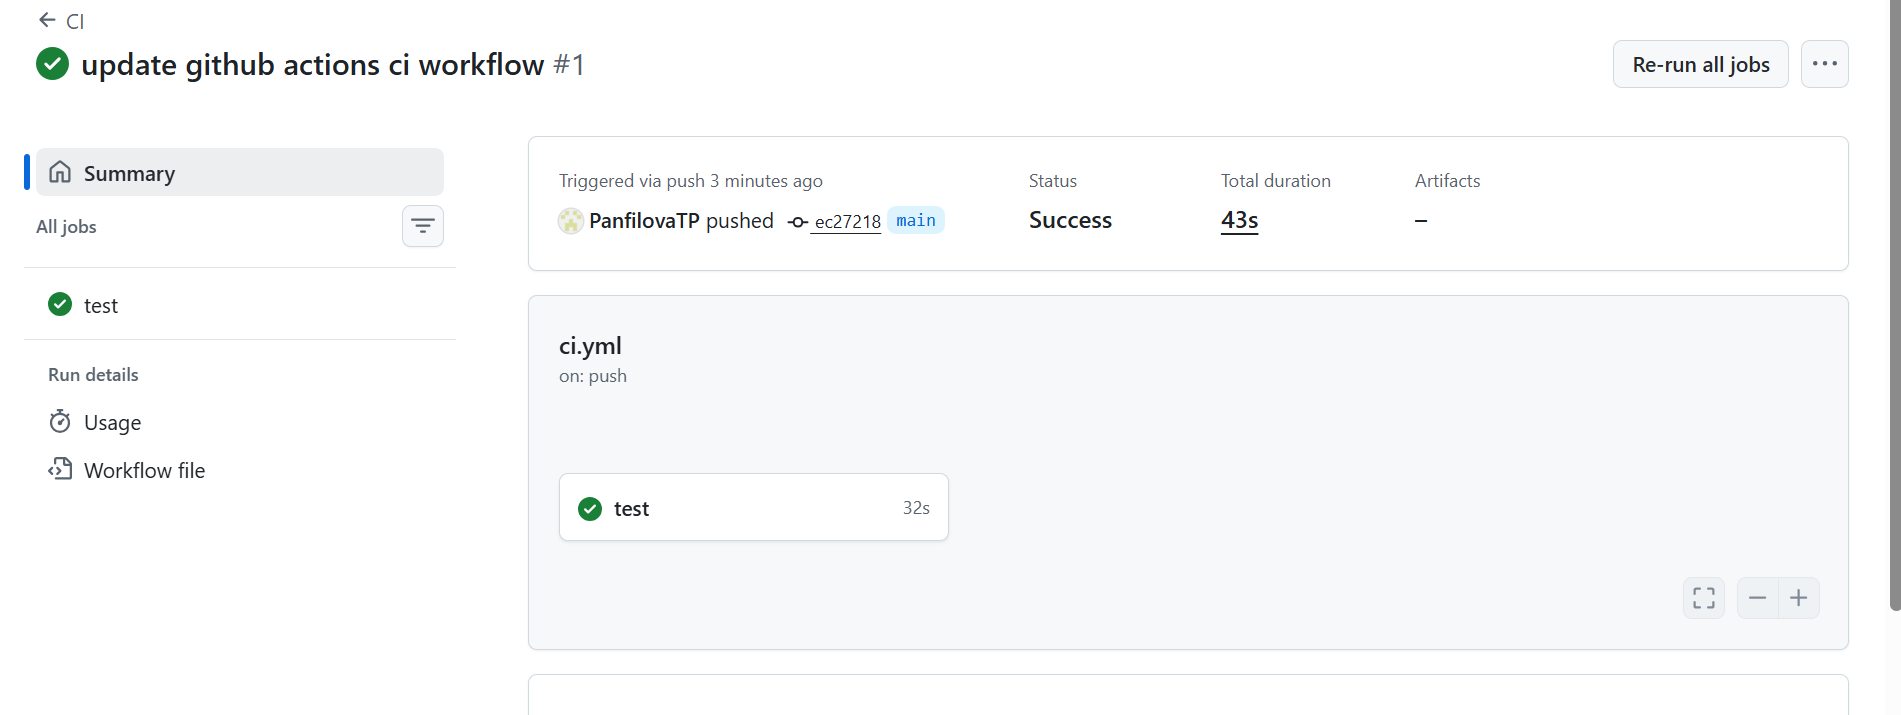



В проекте также есть папка tests с unit-тестами.  
GitHub Actions запускает pytest -q и проверяет работу эндпоинтов /health и /predict.  
Успешный запуск workflow подтверждает, что ML-сервис проходит базовые проверки.


## 6. Итоговое оформление

В этом домашнем задании был собран минимальный CI/CD-конвейер для ML-сервиса. Самой простой частью оказалась упаковка FastAPI-сервиса в Docker, потому что приложение небольшое и имеет понятные endpoint /health и /predict. Более сложной частью стала стратегия деплоя: для ML-модели важно проверять не только техническую доступность сервиса, но и поведение новой версии модели. Из-за отсутствия полноценной обработки ошибок была выбрана стратегия Canary Deployment, так как она снижает риск резкого отказа при выкатывании новой версии. Новая версия сначала получает только небольшую долю трафика, после чего ее можно постепенно довести до 100%. Если новая версия работает нестабильно, через конфигурацию Nginx можно выполнить rollback и вернуть трафик на v1.0.0. Для проверки воспроизводимости ML-пайплайна был использован GitVerse CI/CD как аналог GitLab, а GitHub Actions использовался для автоматической проверки проекта при push в репозиторий. Такой подход применим в реальных проектах, потому что он соединяет тестирование, контроль версий модели, безопасный rollout и возможность отката.

### Дополнительные файлы проекта

В проекте также лежат:

- Dockerfile — сборка Docker-образа ML-сервиса;
- app/main.py — FastAPI-сервис с endpoint /health и /predict;
- docker-compose.canary.yml — запуск двух версий сервиса и Nginx для Canary Deployment;
- docker-compose.blue.yml и docker-compose.green.yml — отдельные compose-файлы для версий v1.0.0 и v1.1.0;
- папка nginx — конфигурации Nginx для режимов 90/10, 50/50, 100% и rollback;
- scripts/switch_canary.sh — скрипт для переключения трафика и rollback;
- tests — unit-тесты для проверки /health и /predict;
- .gitverse/workflows/ci.yml — CI/CD workflow для GitVerse;
- .github/workflows/ci.yml — CI workflow для GitHub Actions;
- .github/workflows/deploy.yml — шаблон workflow для сборки Docker-образа и деплоя через API;
- ab_test_plan.py — расчет параметров A/B-теста для сравнения v1.0.0 и v1.1.0;
- README.md — инструкция по запуску и проверке проекта;
- doc/architecture/decisions/0001-use-canary-deployment-for-ml-service.md — ADR-файл с архитектурным решением.